In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"C:\Users\rajpu\OneDrive\Desktop\Internship\credit_risk_dataset.csv")

In [3]:
df.shape

(1000, 8)

In [4]:
df.head()

,Age,Income,Loan_Amount,Credit_Score,Employment_Years,Education_Level,Housing_Status,Default
0,59,52154.0,11276,823,15,Bachelors,Own,0
1,49,116646.0,43663,315,5,PhD,Own,0
2,35,61157.0,18994,428,8,Masters,Own,1
3,63,52154.0,28499,408,26,Bachelors,Rent,0
4,28,148876.0,28040,832,3,Masters,Own,1


In [5]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [6]:
df.head()

,Age,Income,Loan_Amount,Credit_Score,Employment_Years,Education_Level,Housing_Status,Default
0,59,52154.0,11276,823,15,Bachelors,Own,0
1,49,116646.0,43663,315,5,PhD,Own,0
2,35,61157.0,18994,428,8,Masters,Own,1
3,63,52154.0,28499,408,26,Bachelors,Rent,0
4,28,148876.0,28040,832,3,Masters,Own,1


<Axes: >

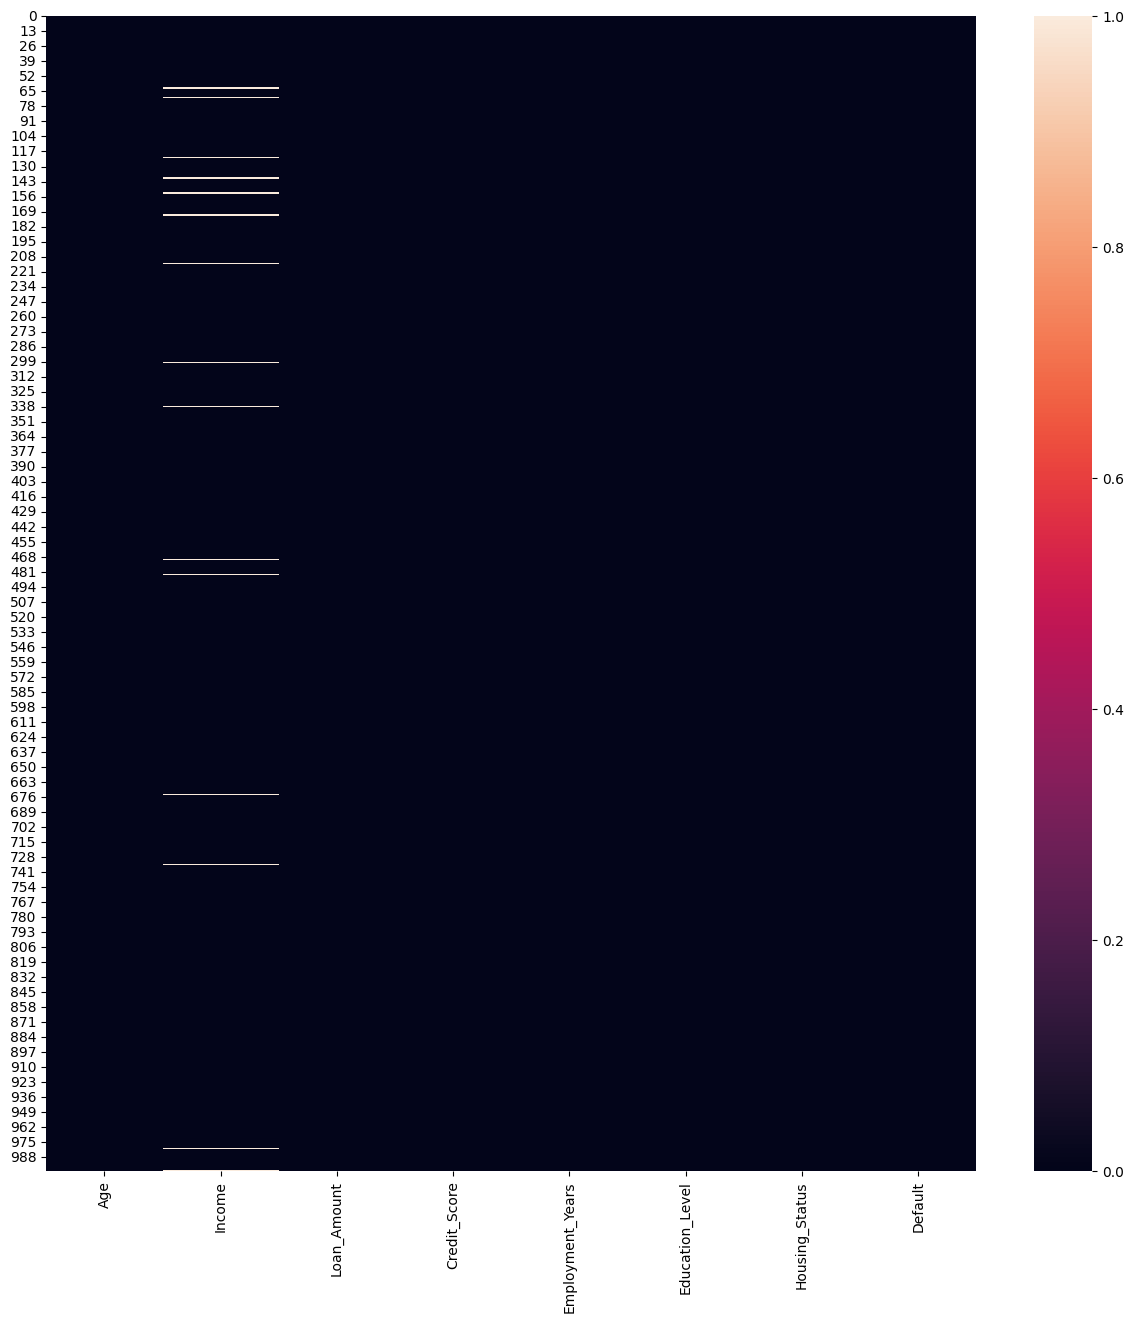

In [7]:
plt.figure(figsize=(15,15))
sns.heatmap(df.isnull())


In [8]:
df.isnull().sum()

Age                  0
Income              15
Loan_Amount          0
Credit_Score         0
Employment_Years     0
Education_Level      0
Housing_Status       0
Default              0
dtype: int64

In [9]:
df_null_clm = df.isnull().sum()/df.shape[0]*100
df_null_clm

Age                 0.0
Income              1.5
Loan_Amount         0.0
Credit_Score        0.0
Employment_Years    0.0
Education_Level     0.0
Housing_Status      0.0
Default             0.0
dtype: float64

In [10]:
df_null_clm[df_null_clm > 20]
null_clm_list = df_null_clm[df_null_clm > 20].index
null_clm_list

Index([], dtype='str')

In [11]:
df_drop_clm = df.drop(columns=null_clm_list)

In [12]:
df_num_clm = df_drop_clm.select_dtypes(include=['int','float'])

<Axes: >

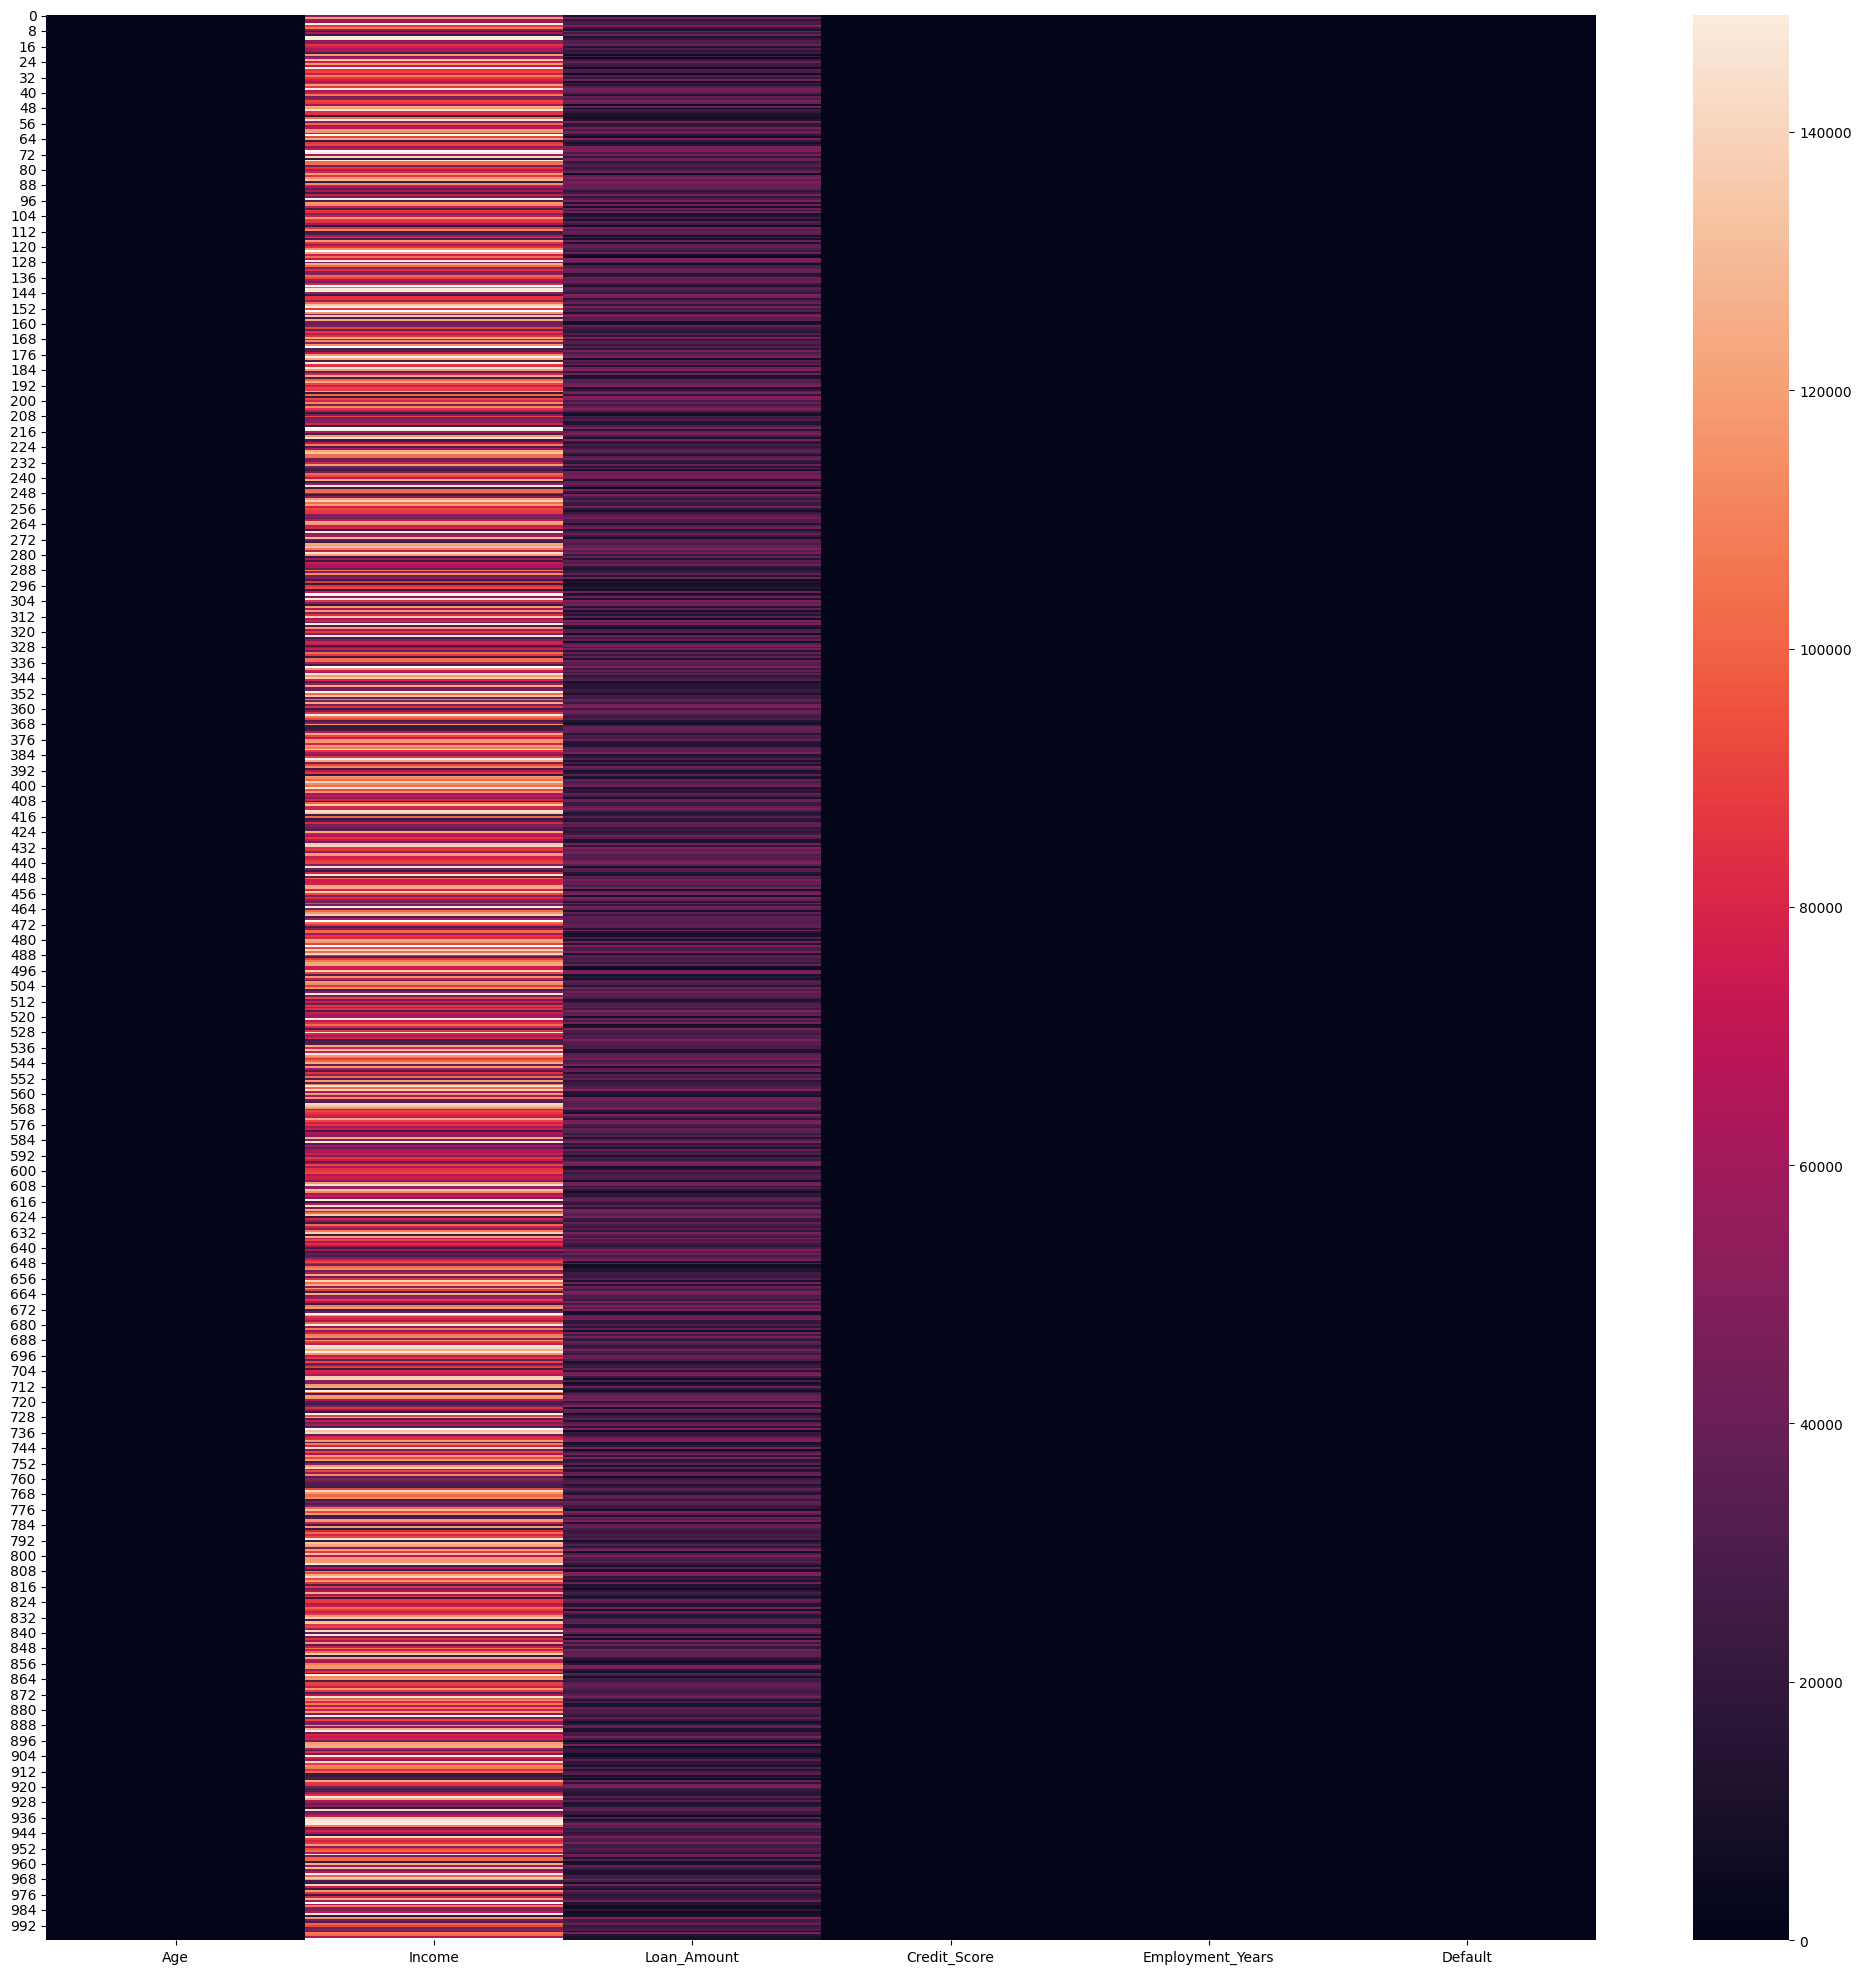

In [13]:
plt.figure(figsize=(25,25))
sns.heatmap(df_num_clm)

In [14]:
df_numeric = df_num_clm.dropna()


In [15]:
df_numeric.isnull().sum().sum()

np.int64(0)

<Axes: >

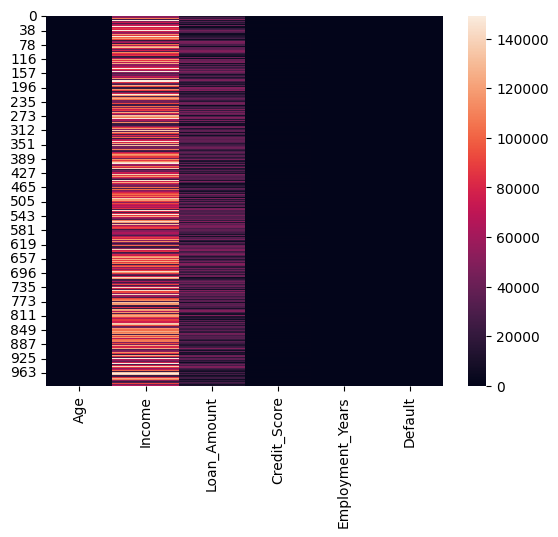

In [16]:
sns.heatmap(df_numeric)


In [17]:
df_cat = df_drop_clm.select_dtypes(include=['object'])

C:\Users\rajpu\AppData\Local\Temp\ipykernel_12308\3825809238.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df_cat = df_drop_clm.select_dtypes(include=['object'])


In [18]:
df_cat.isnull().sum().sum()

np.int64(0)

In [19]:
df_cat1 = df_cat.dropna()
df_cat1.isnull().sum().sum()

np.int64(0)

In [20]:
df_clean = df.dropna()

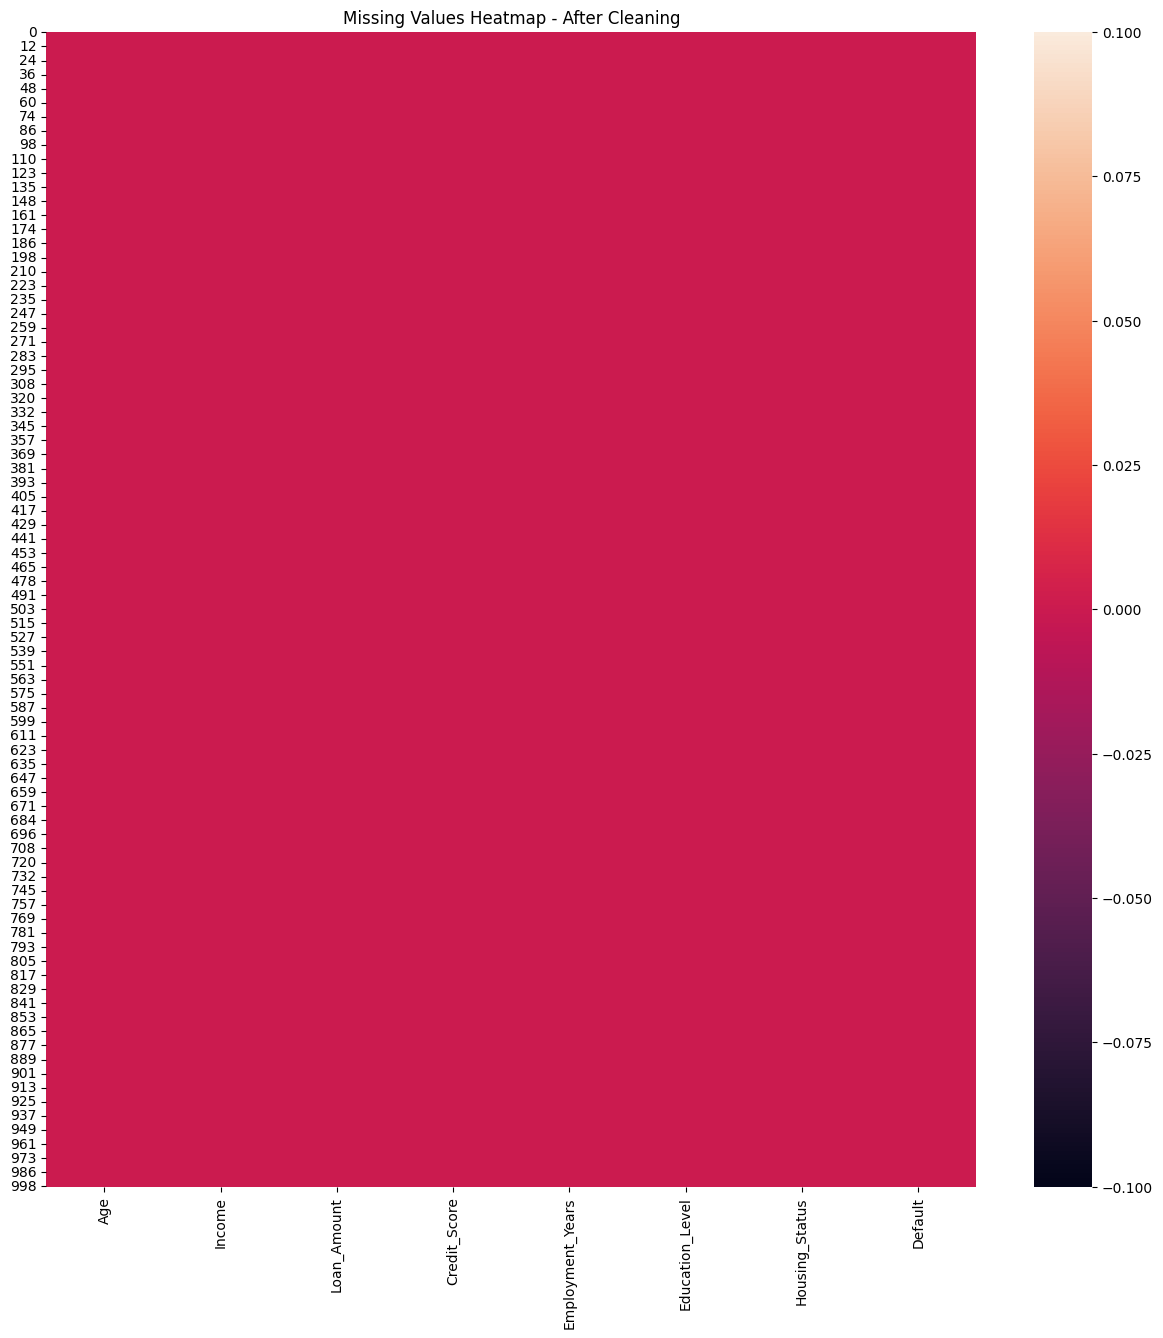

In [21]:
plt.figure(figsize=(15,15))
sns.heatmap(df_clean.isnull())
plt.title("Missing Values Heatmap - After Cleaning")
plt.show()

In [22]:
print("Final shape after cleaning:", df_clean.shape)
print("Total null values after cleaning:", df_clean.isnull().sum().sum())

Final shape after cleaning: (985, 8)
Total null values after cleaning: 0


In [23]:
print("\nDuplicate Rows :", df.duplicated().sum())


Duplicate Rows : 0


In [24]:
print(df.columns.tolist())

['Age', 'Income', 'Loan_Amount', 'Credit_Score', 'Employment_Years', 'Education_Level', 'Housing_Status', 'Default']


In [25]:
X = df.drop(columns=['Default'])
y = df['Default']

In [26]:
df['Income'] = df['Income'].fillna(df['Income'].median())

In [27]:
print(df.columns)

Index(['Age', 'Income', 'Loan_Amount', 'Credit_Score', 'Employment_Years',
       'Education_Level', 'Housing_Status', 'Default'],
      dtype='str')


In [28]:
df = pd.get_dummies(
    df,
    columns=["Education_Level", "Housing_Status"],
    drop_first=True,
    dtype=int
)

In [29]:
X = df.drop("Default", axis=1)
y = df["Default"]

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [32]:
X_train.dtypes

Age                              int64
Income                         float64
Loan_Amount                      int64
Credit_Score                     int64
Employment_Years                 int64
Education_Level_High School      int64
Education_Level_Masters          int64
Education_Level_PhD              int64
Housing_Status_Own               int64
Housing_Status_Rent              int64
dtype: object

In [33]:
X_train.head()

,Age,Income,Loan_Amount,Credit_Score,Employment_Years,Education_Level_High School,Education_Level_Masters,Education_Level_PhD,Housing_Status_Own,Housing_Status_Rent
90,44,39029.0,36890,583,24,0,0,1,1,0
931,43,24018.0,35932,439,7,0,0,1,0,1
116,64,29446.0,9114,361,12,1,0,0,0,0
631,61,107487.0,19571,403,14,0,0,0,0,0
238,60,102870.0,39084,534,0,0,0,0,0,1


In [34]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [35]:
model = LogisticRegression()
model.fit(X_train_scaled, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [36]:
y_pred = model.predict(X_test_scaled)

In [37]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [38]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.86

Confusion Matrix:
 [[172   0]
 [ 28   0]]

Classification Report:
               precision    recall  f1-score   support

           0       0.86      1.00      0.92       172
           1       0.00      0.00      0.00        28

    accuracy                           0.86       200
   macro avg       0.43      0.50      0.46       200
weighted avg       0.74      0.86      0.80       200



C:\Users\rajpu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\rajpu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\rajpu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_clas